In [11]:
import pandas as pd

# Load the Opal usage data to explore its structure and contents
file_path = 'opal_all_mode.csv'
opal_data = pd.read_csv(file_path)

# Show basic information and the first few rows of the data
opal_data.info(), opal_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year_Month   448 non-null    object 
 1   Card Type    448 non-null    object 
 2   Travel_Mode  448 non-null    object 
 3   Trip         448 non-null    float64
dtypes: float64(1), object(3)
memory usage: 14.1+ KB


(None,
   Year_Month Card Type  Travel_Mode       Trip
 0    2024-01     Adult        Ferry   504780.0
 1    2024-01     Adult   Light Rail  1203585.0
 2    2024-01     Adult        Metro   709103.0
 3    2024-01     Adult        Train  9987934.0
 4    2024-01     Adult  unallocated        5.0)

In [13]:
print(opal_data.columns)

Index(['Year_Month', 'Card Type', 'Travel_Mode', 'Trip'], dtype='object')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot aesthetics
sns.set(style='whitegrid')

### What insights can be gained from the distribution of trips across different transport modes?

The first visualization displays the total number of trips for each transport mode (bus, train, ferry, etc.). The goal is to understand which mode of transport is most utilized by passengers.


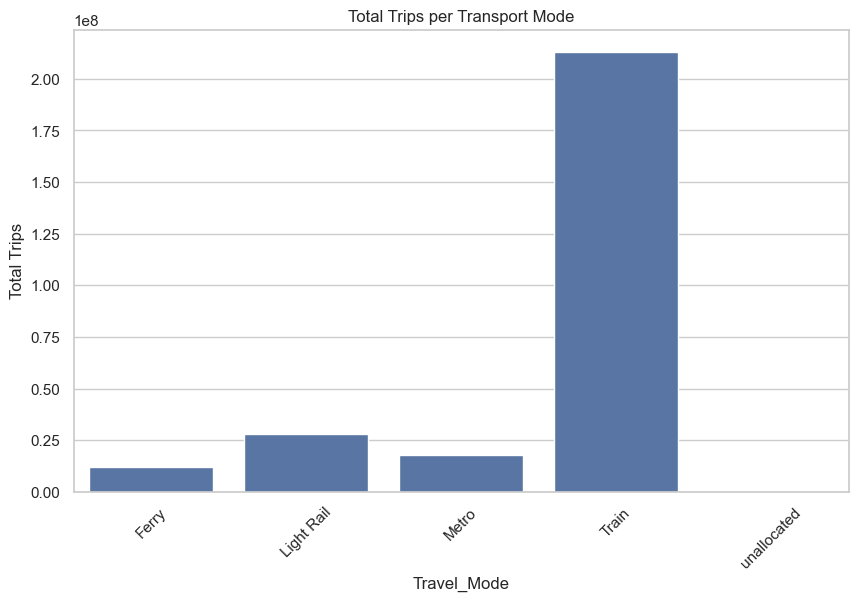

In [26]:
# Univariate analysis - Distribution of trips across different transport modes
plt.figure(figsize=(10, 6))
sns.barplot(data=opal_data, x='Travel_Mode', y='Trip', estimator=sum, errorbar=None)
plt.title('Total Trips per Transport Mode')
plt.ylabel('Total Trips')
plt.xticks(rotation=45)
plt.show()

### How does the total number of trips vary based on different card types?

The second plot analyzes trips per card type (e.g., Adult, Concession, Student, etc.). This can help identify which types of cards are most frequently used, shedding light on demographic preferences or economic factors influencing public transport usage.


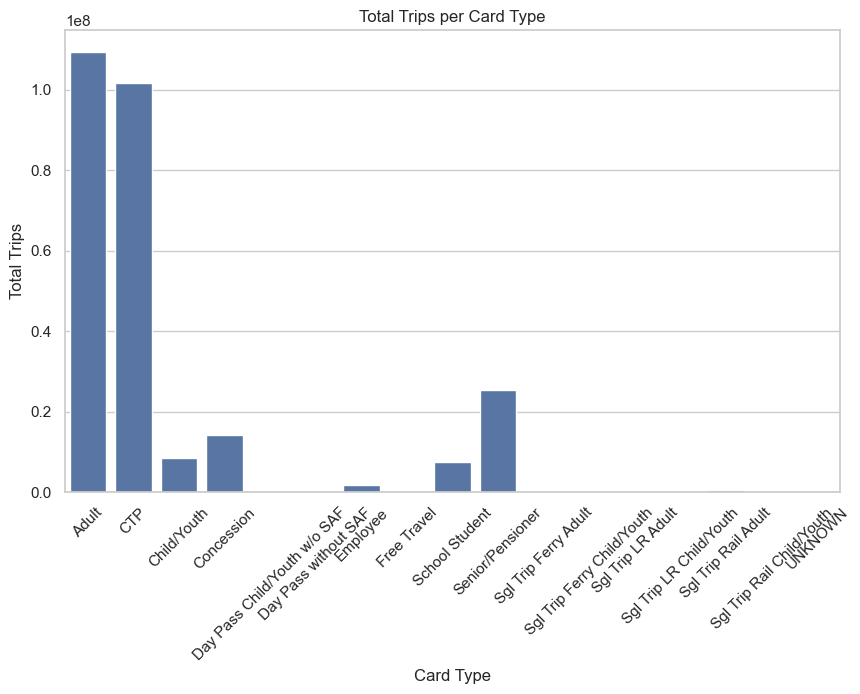

In [29]:
# Univariate analysis - Distribution of trips per card type
plt.figure(figsize=(10, 6))
sns.barplot(data=opal_data, x='Card Type', y='Trip', estimator=sum, errorbar=None)
plt.title('Total Trips per Card Type')
plt.ylabel('Total Trips')
plt.xticks(rotation=45)
plt.show()

### What time-based trends can be observed in the usage of different transport modes over the period in question?

The third plot is a time series analysis of trips over time, broken down by transport mode. It aims to identify patterns, trends, or seasonal variations in the usage of buses, trains, ferries, etc., over different months or years.


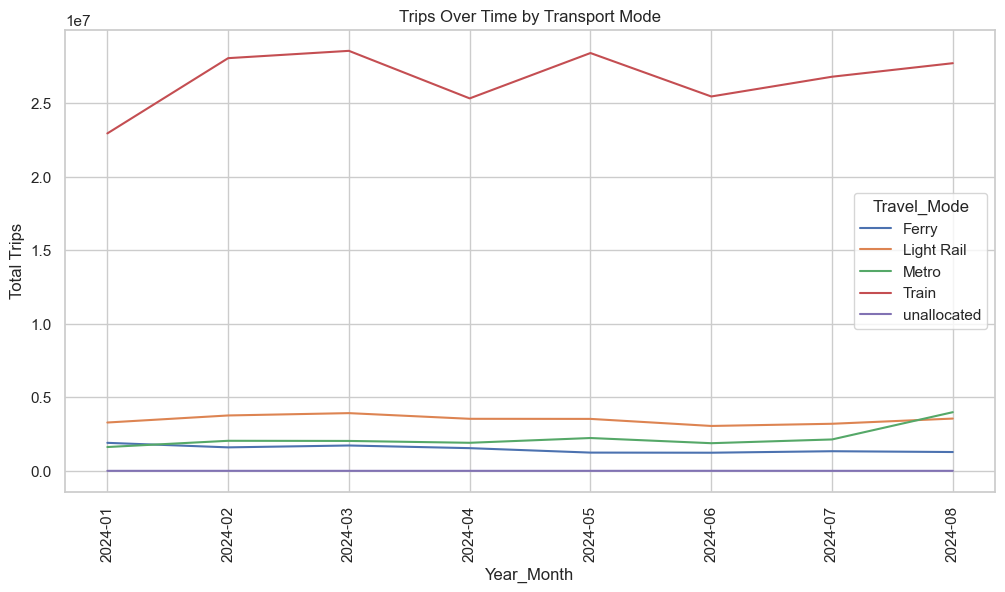

In [31]:
# Time series analysis - Trends over Year_Month
plt.figure(figsize=(12, 6))
sns.lineplot(data=opal_data, x='Year_Month', y='Trip', hue='Travel_Mode', estimator=sum, errorbar=None)
plt.title('Trips Over Time by Transport Mode')
plt.ylabel('Total Trips')
plt.xticks(rotation=90)
plt.show()

 
1. **Why is OneHotEncoding used, and how does it impact the model?**
   - In this code, `pd.get_dummies` is applied to convert categorical features (`'Card Type'` and `'Travel_Mode'`) into numerical values. This question helps to explore the necessity and impact of transforming categorical data into a format that regression models can interpret.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
from sklearn.preprocessing import OneHotEncoder
# Step 1: Preprocessing - Convert categorical features into numerical values
opal_data_encoded = pd.get_dummies(opal_data, columns=['Card Type', 'Travel_Mode'])

2. **How is the data split into training and test sets, and why is this necessary?**
   - This question focuses on the significance of splitting the data using `train_test_split` to evaluate the model’s performance on unseen data and prevent overfitting.

In [49]:
# Step 2: Split the data into features (X) and target (y)
X = opal_data_encoded.drop(columns=['Trip', 'Year_Month'])  # Drop target and date column
y = opal_data_encoded['Trip']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 **What are the differences between linear regression and polynomial regression?**
   - This question prompts the user to compare how linear and polynomial regression models capture the relationship between the features and the target, and why polynomial regression may perform better in certain cases.


 **How are the models evaluated in terms of performance, and why are MSE and R-squared used?**
   - This question encourages an analysis of the evaluation metrics (`mean_squared_error`, `r2_score`) to understand model performance, comparing both linear and polynomial regression results.


In [38]:
# Step 3: Linear Regression Model
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_linear = linear_reg.predict(X_test)

# Evaluate the linear model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print(f'Linear Regression MSE: {mse_linear}, R-squared: {r2_linear}')

Linear Regression MSE: 1668922250474.0444, R-squared: -0.1931095065406805


**Why is PolynomialFeatures used in this code, and how does it improve the model?**
   - This explores the role of `PolynomialFeatures` in extending the model to capture non-linear relationships between features and the target variable.

In [36]:
# Step 4: Polynomial Regression Model
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_poly_train, y_train)
y_pred_poly = poly_reg.predict(X_poly_test)

# Evaluate the polynomial model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f'Polynomial Regression MSE: {mse_poly}, R-squared: {r2_poly}')

Polynomial Regression MSE: 32432503700.711113, R-squared: 0.9768140616045816


**What is the purpose of using Recursive Feature Elimination (RFE)?**
   - This question encourages reflection on how RFE helps in feature selection by eliminating less important features, leading to more efficient and interpretable models.

**How does RFE help in identifying the most important features for predicting trips?**
   - This examines how the important features selected by RFE provide insights into which factors are most influential in predicting the target variable (`Trip`).

     **How does the performance of linear and polynomial regression models compare?**
   - This question compares the performance of both models in terms of MSE and R-squared values, prompting the user to analyze which model fits the data better and why.

In [34]:
# Step 5: Recursive Feature Elimination (RFE) to find important features
rfe = RFE(estimator=linear_reg, n_features_to_select=5)
rfe.fit(X_train, y_train)

# Check the selected important features
important_features = X.columns[rfe.support_]
print(f'Important features: {important_features}')

Important features: Index(['Card Type_Adult', 'Card Type_CTP', 'Travel_Mode_Ferry',
       'Travel_Mode_Train', 'Travel_Mode_unallocated'],
      dtype='object')


## Explanation

- **Linear Regression**: A baseline linear model is built using features from the Opal dataset to predict the number of trips.
- **Polynomial Regression**: We improve the baseline model by adding polynomial features (degree 2) to capture non-linear relationships between the features and the target variable.
- **RFE (Recursive Feature Elimination)**: RFE is used to find the top 5 important features that contribute the most to predicting the number of trips. This helps in identifying the most relevant factors influencing public transport usage.
ing predictive models or strategic planning.


## Evaluation

The performance of both the linear and polynomial regression models was evaluated using the following metrics:

- **MSE (Mean Squared Error)**: This metric measures the average squared difference between the predicted and actual values. A lower MSE indicates better performance.
- **R-squared (R²)**: This metric explains how well the features in the model predict the target variable (Trips). R² values close to 1 indicate stronger predictive power.

The important features identified by **Recursive Feature Elimination (RFE)** provide insights into the most influential factors impacting public transport usage. This helps us understand which features contribute the most to the predictions and enables us to refine our model further.


# How do the various data preprocessing steps, model training methods (Logistic Regression and KNN), and clustering techniques (K-Means) work together to analyze and predict usage patterns in the Opal dataset, and what insights can be derived from these analyses?


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95        29
           1       0.97      0.98      0.98        61

    accuracy                           0.97        90
   macro avg       0.97      0.96      0.96        90
weighted avg       0.97      0.97      0.97        90

Confusion Matrix:
 [[27  2]
 [ 1 60]]
KNN Mean Squared Error: 2166251669140.6475


C:\Users\Prash\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


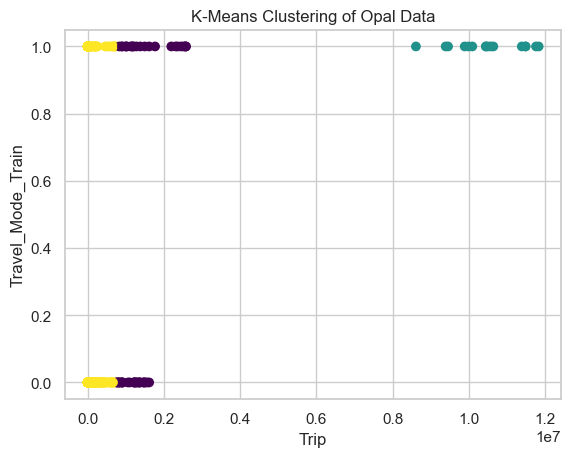

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# Convert categorical variables to numeric using One-Hot Encoding
opal_data = pd.get_dummies(opal_data, drop_first=True)

# Create a binary target variable for high usage (e.g., above 100 trips)
opal_data['High_Usage'] = (opal_data['Trip'] > 100).astype(int)

# Split the data into features (X) and target (y)
X = opal_data.drop(columns=['Trip', 'High_Usage']) 
y_class = opal_data['High_Usage']  

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Step 2: Logistic Regression for Classification
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

# Evaluate the logistic regression model
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logistic))

# Step 3: KNN for Prediction
# Now we can use KNN to predict the actual number of trips (for example)
y_trip = opal_data['Trip']  # Target variable for KNN
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y_trip, test_size=0.2, random_state=42)

knn_model = KNeighborsRegressor(n_neighbors=5) 
knn_model.fit(X_train_knn, y_train_knn)
y_pred_knn = knn_model.predict(X_test_knn)

# Evaluate KNN prediction
knn_mse = np.mean((y_test_knn - y_pred_knn) ** 2)  # Mean Squared Error
print(f"KNN Mean Squared Error: {knn_mse}")

# Step 4: K-Means Clustering
# Let's say we want to cluster based on a few features, e.g., 'Trip' and 'Travel_Mode_Train'
# Select features for clustering
features_for_clustering = opal_data[['Trip', 'Travel_Mode_Train']]  

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Choose number of clusters
opal_data['Cluster'] = kmeans.fit_predict(features_for_clustering)

# Visualize Clusters
plt.scatter(opal_data['Trip'], opal_data['Travel_Mode_Train'], c=opal_data['Cluster'], cmap='viridis')
plt.title('K-Means Clustering of Opal Data')
plt.xlabel('Trip')
plt.ylabel('Travel_Mode_Train')
plt.show()


# Insights from the Opal Dataset Analysis

1. **High Usage Classification**: The Logistic Regression model categorizes users based on their trip frequency, specifically identifying high usage (more than 100 trips). This classification helps stakeholders understand which users contribute significantly to transportation demand, enabling targeted strategies to improve service delivery.

2. **Trip Prediction Using KNN**: The K-Nearest Neighbors (KNN) regression model predicts the number of trips for users, providing insights into expected passenger behavior. The evaluation of KNN performance using Mean Squared Error (MSE) reveals how well the model performs, with lower MSE indicating better prediction accuracy.

3. **User Clustering with K-Means**: The K-Means clustering algorithm segments users based on trip counts and their preferred travel modes, revealing distinct behavioral patterns. Visualizing these clusters helps in identifying different user groups, which can inform resource allocation and service enhancements.

4. **Data Preprocessing Importance**: The use of One-Hot Encoding to convert categorical variables into numerical representations is essential for the efficacy of machine learning models. This transformation allows algorithms to process the data effectively, enhancing overall model performance.

5. **Comprehensive Analytical Approach**: The integration of logistic regression, KNN regression, and K-Means clustering provides a multi-dimensional perspective on user behavior. This comprehensive approach delivers valuable insights for optimizing transportation services, addressing user needs, and improving overall efficiency.
